# 3단계 — ML 베이스라인 모델 (TF-IDF + Logistic Regression)

GPU 없이도 수 초 안에 학습·추론이 가능한 경량 모델입니다.

파이프라인:
```
텍스트 → TF-IDF 벡터화 → Logistic Regression → 클래스 확률
```

In [1]:
import sys
sys.path.insert(0, '..')

from src.data.preprocessor import Preprocessor
from src.data.loader import load_dataset
from src.models.ml_model import MLSpamClassifier

print('모듈 로드 완료')

모듈 로드 완료


## 데이터 로드 & 전처리

In [2]:
pre = Preprocessor(use_konlpy=False)

data = load_dataset(
    csv_path='../data/korean_spam_dataset.csv',
    preprocessor=pre,
    train_ratio=0.8,
    val_ratio=0.1,
    random_state=42,
)

[데이터] 총 5000개 로드 | 스팸: spamspamhamspamhamspamspamspamspamspamhamspamspamspamhamhamspamhamspamhamhamhamspamhamhamspamhamhamspamspamspamhamhamspamhamhamspamspamspamspamhamhamhamhamspamspamspamhamhamspamspamhamspamspamhamspamspamhamhamspamspamhamhamhamhamspamhamhamspamhamhamhamhamspamspamhamhamhamhamspamspamspamhamhamhamspamhamhamhamspamspamspamhamspamspamhamhamspamspamhamspamhamhamhamspamhamspamhamhamhamhamspamhamhamhamspamhamhamspamhamhamhamspamspamhamhamspamspamspamhamspamspamspamhamspamspamhamhamspamhamhamhamhamspamhamspamspamhamspamspamhamspamhamspamspamspamspamhamspamhamhamspamhamhamhamspamspamspamhamspamhamhamspamhamhamspamhamhamspamhamhamspamspamhamhamhamspamhamhamspamhamhamspamhamhamhamspamhamhamspamhamspamhamspamspamhamspamhamhamhamhamhamhamspamhamhamhamhamspamspamhamhamspamspamspamspamspamspamhamspamhamspamspamspamspamhamspamhamspamhamspamhamhamhamspamspamhamhamspamspamhamhamspamhamhamspamhamhamhamhamspamspamspamhamhamspamspamhamspamspamhamspamspamhamhamhamhamhamspamspamspamspa

## 모델 학습

In [3]:
model = MLSpamClassifier(
    max_features=50_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    C=1.0,
    class_weight='balanced',
    spam_threshold=0.7,
)

model.fit(data.X_train, data.y_train, data.X_val, data.y_val)

[ML] 학습 시작...
[ML] 학습 완료
[ML] Validation 결과:
              precision    recall  f1-score   support

         ham       1.00      1.00      1.00       300
        spam       1.00      1.00      1.00       200

    accuracy                           1.00       500
   macro avg       1.00      1.00      1.00       500
weighted avg       1.00      1.00      1.00       500



c:\Users\ion01\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


## Test 세트 최종 평가

In [ ]:
import time
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

t0 = time.perf_counter()
results = model.predict(data.X_test)
elapsed_ms = (time.perf_counter() - t0) * 1000

y_pred = [r.label for r in results]

print(classification_report(data.y_test, y_pred, target_names=['ham', 'spam']))
print(f'추론 시간: {elapsed_ms:.1f}ms | 평균 {elapsed_ms/len(data.X_test):.2f}ms/건')

In [ ]:
cm = confusion_matrix(data.y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['ham', 'spam'])
disp.plot(cmap='Blues')
plt.title('혼동 행렬')
plt.tight_layout()
plt.show()

## 중요 특성 (TF-IDF 가중치 상위 단어)

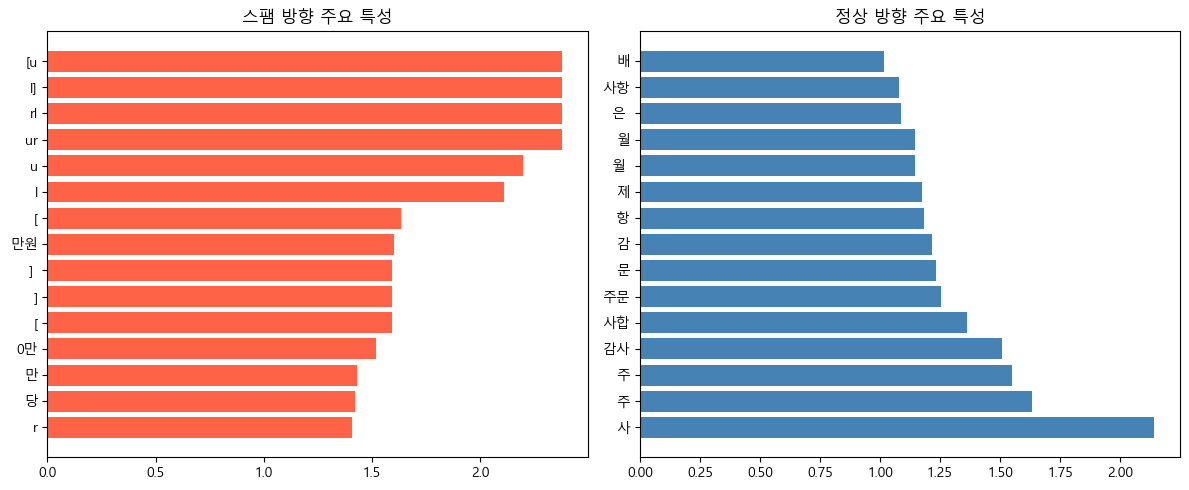

In [5]:
import numpy as np

tfidf  = model._pipeline.named_steps['tfidf']
clf    = model._pipeline.named_steps['clf']
names  = tfidf.get_feature_names_out()
coefs  = clf.coef_[0]  # ham=음수, spam=양수

top_n = 15
spam_idx = np.argsort(coefs)[-top_n:][::-1]
ham_idx  = np.argsort(coefs)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].barh(names[spam_idx][::-1], coefs[spam_idx][::-1], color='tomato')
axes[0].set_title('스팸 방향 주요 특성')

axes[1].barh(names[ham_idx], np.abs(coefs[ham_idx]), color='steelblue')
axes[1].set_title('정상 방향 주요 특성')

plt.tight_layout()
plt.show()

## 모델 저장

In [ ]:
import os
os.makedirs('../artifacts', exist_ok=True)
model.save('../artifacts/ml_model.joblib')
print('저장 완료!')

## 직접 테스트

In [ ]:
test_cases = [
    ('무료 대출 1억 지금 바로 신청', '신용등급 상관없이 당일 대출 가능합니다. 지금 클릭하세요!'),
    ('내일 회의 자료 공유드립니다', '안녕하세요. 내일 오전 10시 회의 자료 첨부드립니다. 검토 부탁드립니다.'),
    ('당신이 선택되었습니다!', '축하합니다! 1등 당첨! 지금 바로 수령하세요. 010-0000-0000'),
]

for subject, body in test_cases:
    text = pre.preprocess(subject, body)
    result = model.predict_single(text)
    print(f'[{result.label.upper():4s}] 신뢰도={result.confidence:.2%} | 제목: {subject}')